# Step 04: Explore the cleaned UCI household load

Source: `data/processed/uci_1min.parquet` (from `pipeline/clean_uci.py`): one `load_w` value per minute,
Dec 2006 to Nov 2010. Gaps longer than 5 minutes are still NaN and are skipped by every average below.

Figures are saved to `results/figures/`.

In [2]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Find the project root whether the notebook runs from notebooks/ or the root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir())
FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

load = pd.read_parquet(ROOT / "data" / "processed" / "uci_1min.parquet")["load_w"]
print(f"{len(load):,} minutes, {load.index[0]} -> {load.index[-1]}, {load.isna().sum():,} still missing")

2,075,259 minutes, 2006-12-16 17:24:00 -> 2010-11-26 21:02:00, 25,903 still missing


In [3]:
# Shared style: light surface, recessive grid/axes, thin marks, fixed series colors.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
SERIES_1, SERIES_2 = "#2a78d6", "#eb6834"  # categorical slots 1 (blue) and 2 (orange)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "axes.edgecolor": GRID, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False,
})
watts = FuncFormatter(lambda v, _: f"{v:,.0f}")

def save(fig, name):
    path = FIG_DIR / name
    fig.savefig(path)
    print(f"Saved {path.relative_to(ROOT).as_posix()}")

## 1. Daily profile: weekdays vs weekends
Average load for each minute of the day, split by Monday-Friday and Saturday-Sunday.

Saved results/figures/step04_daily_profile.png


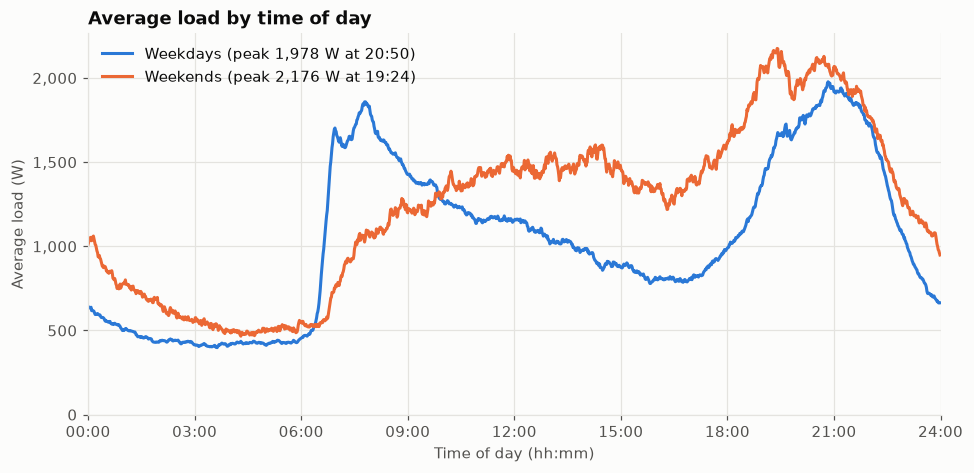

In [4]:
minute_of_day = load.index.hour * 60 + load.index.minute
is_weekend = load.index.dayofweek >= 5
profile = load.groupby([is_weekend, minute_of_day]).mean().unstack(0)
profile.columns = ["Weekdays", "Weekends"]
hours = profile.index / 60

fig, ax = plt.subplots(figsize=(10, 4.5))
for name, color in [("Weekdays", SERIES_1), ("Weekends", SERIES_2)]:
    peak = profile[name].idxmax()
    ax.plot(hours, profile[name], color=color,
            label=f"{name} (peak {profile[name].max():,.0f} W at {peak // 60:02d}:{peak % 60:02d})")
ax.set(xlim=(0, 24), ylim=(0, None), title="Average load by time of day",
       xlabel="Time of day (hh:mm)", ylabel="Average load (W)")
ax.set_xticks(range(0, 25, 3), [f"{h:02d}:00" for h in range(0, 25, 3)])
ax.yaxis.set_major_formatter(watts)
ax.legend(loc="upper left")
save(fig, "step04_daily_profile.png")
plt.show()

## 2. One ordinary week of raw 1-minute load
"Ordinary" is picked by rule rather than by eye: a complete Monday-Sunday week with no missing minutes,
outside the December/January, August and Easter-to-May holiday-prone months, whose mean load is closest
to the median weekly mean of all such weeks.

187 complete weeks, 109 candidates; chose week of Mon 29 Sep 2008, mean 1,127 W (median weekly mean 1,127 W)
Saved results/figures/step04_one_week.png


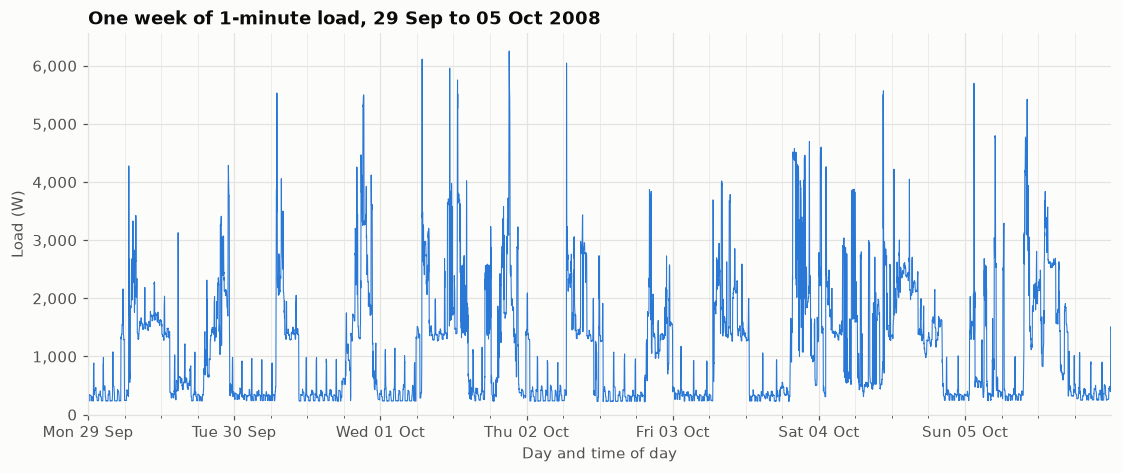

In [5]:
week_start = load.index.normalize() - pd.to_timedelta(load.index.dayofweek, unit="D")
weekly = load.groupby(week_start).agg(["mean", "count", "size"])
complete = weekly[(weekly["count"] == 7 * 1440) & (weekly["size"] == 7 * 1440)]
ordinary_months = ~complete.index.month.isin([12, 1, 4, 5, 8])
candidates = complete[ordinary_months]
start = (candidates["mean"] - candidates["mean"].median()).abs().idxmin()
week = load[start : start + pd.Timedelta(days=7) - pd.Timedelta(minutes=1)]
print(f"{len(complete)} complete weeks, {len(candidates)} candidates; chose week of {start:%a %d %b %Y}, "
      f"mean {week.mean():,.0f} W (median weekly mean {candidates['mean'].median():,.0f} W)")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(week.index, week, color=SERIES_1, linewidth=0.7)
ax.set(xlim=(week.index[0], week.index[-1]), ylim=(0, None),
       title=f"One week of 1-minute load, {start:%d %b} to {week.index[-1]:%d %b %Y}",
       xlabel="Day and time of day", ylabel="Load (W)")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
ax.grid(which="minor", axis="x", color=GRID, linewidth=0.4)
ax.yaxis.set_major_formatter(watts)
save(fig, "step04_one_week.png")
plt.show()

## 3. Distribution of 1-minute load
50 W bins. The count axis is log-scaled so the long tail of high-load minutes stays visible.

Saved results/figures/step04_distribution.png


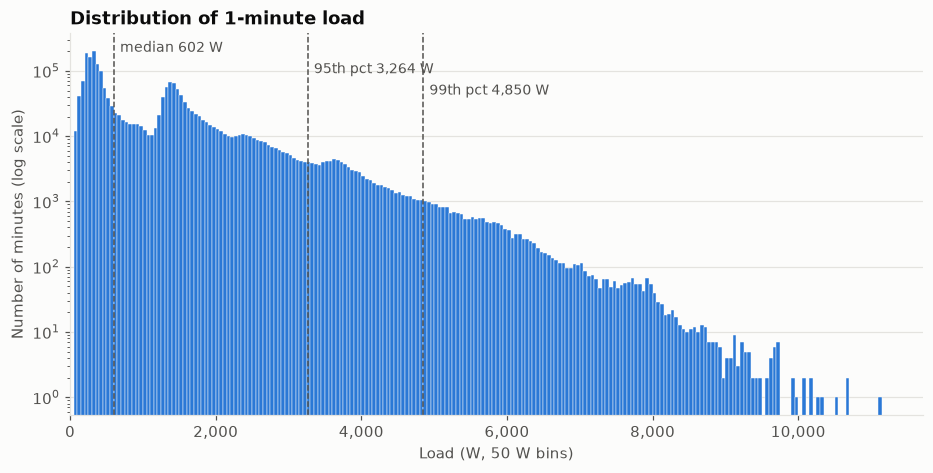

In [6]:
valid = load.dropna()
bins = range(0, int(valid.max()) + 50, 50)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(valid, bins=bins, color=SERIES_1, edgecolor=SURFACE, linewidth=0.3)
ax.set_yscale("log")
for i, (q, label) in enumerate([(0.5, "median"), (0.95, "95th pct"), (0.99, "99th pct")]):
    v = valid.quantile(q)
    ax.axvline(v, color=INK_2, linewidth=1, linestyle="--")
    ax.annotate(f"{label} {v:,.0f} W", (v, 1), xycoords=("data", "axes fraction"),
                xytext=(4, -12 - 14 * i), textcoords="offset points", color=INK_2, fontsize=9)
ax.set(xlim=(0, None), title="Distribution of 1-minute load",
       xlabel="Load (W, 50 W bins)", ylabel="Number of minutes (log scale)")
ax.xaxis.set_major_formatter(watts)
ax.grid(axis="x", visible=False)
save(fig, "step04_distribution.png")
plt.show()

## 4. Mean load per month, Dec 2006 to Nov 2010
Each point is the mean of that month's available minutes. December 2006 starts on the 16th, and months with
long gaps are averaged over fewer minutes; the coverage is printed below.

            count   size  coverage_pct
timestamp                             
2007-04-01  39477  43200          91.4
2009-06-01  39895  43200          92.3
2009-08-01  43749  44640          98.0
2010-01-01  41511  44640          93.0
2010-03-01  42613  44640          95.5
2010-08-01  37414  44640          83.8
2010-09-01  37963  43200          87.9
Saved results/figures/step04_monthly_mean.png


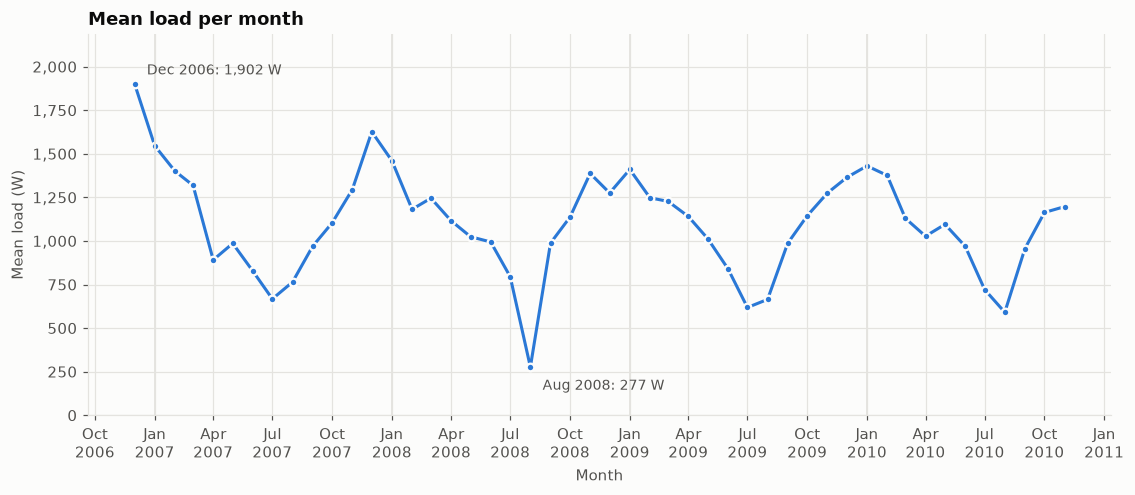

In [7]:
monthly = load.resample("MS").agg(["mean", "count", "size"])
monthly["coverage_pct"] = 100 * monthly["count"] / monthly["size"]
print(monthly[monthly["coverage_pct"] < 99][["count", "size", "coverage_pct"]].round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly["mean"], color=SERIES_1, marker="o", markersize=5,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
for year in sorted(set(monthly.index.year))[1:]:
    ax.axvline(pd.Timestamp(year=year, month=1, day=1), color=GRID, linewidth=1.2)
lo, hi = monthly["mean"].idxmin(), monthly["mean"].idxmax()
for ts, va in [(hi, "bottom"), (lo, "top")]:
    ax.annotate(f"{ts:%b %Y}: {monthly.loc[ts, 'mean']:,.0f} W", (ts, monthly.loc[ts, "mean"]),
                xytext=(8, 4 if va == "bottom" else -8), textcoords="offset points",
                ha="left", va=va, color=INK_2, fontsize=9)
ax.set(ylim=(0, monthly["mean"].max() * 1.15), title="Mean load per month",
       xlabel="Month", ylabel="Mean load (W)")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.yaxis.set_major_formatter(watts)
save(fig, "step04_monthly_mean.png")
plt.show()